In [6]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.shape

(7043, 21)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**The dataset contains 7,043 customer records with 21 features.**
- Majority of features are categorical (object type).
- Numerical features include tenure, MonthlyCharges, and TotalCharges.
- Target variable: **Churn**
- Data includes customer demographics, subscription details, and billing information.

This structure allows segmentation analysis and churn driver identification.

In [11]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
df.dropna(inplace=True)

df.shape

(7032, 21)

**Data Cleaning Summary**

- Identified 11 missing values in TotalCharges.
- Removed incomplete records (<0.2% of dataset).
- Ensured clean financial data for accurate churn and revenue analysis.

Dataset is now ready for KPI and segmentation analysis.

In [13]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100
churn_rate

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

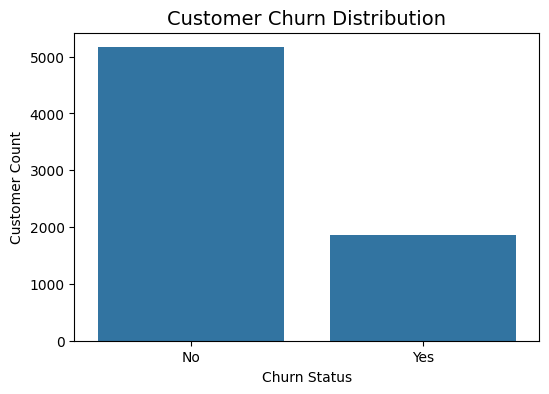

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution", fontsize=14)
plt.xlabel("Churn Status")
plt.ylabel("Customer Count")
plt.show()

**Overall Churn Rate Analysis**

The overall churn rate is **26.58%**, meaning more than one in four customers discontinue their subscription.

In subscription-based industries, churn rates above 20% indicate substantial revenue risk.

This level of attrition suggests:
- Weak customer retention mechanisms
- Potential dissatisfaction in specific segments
- Opportunities for targeted retention strategies

Reducing churn by even 5% could significantly increase long-term revenue and customer lifetime value.

In [15]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


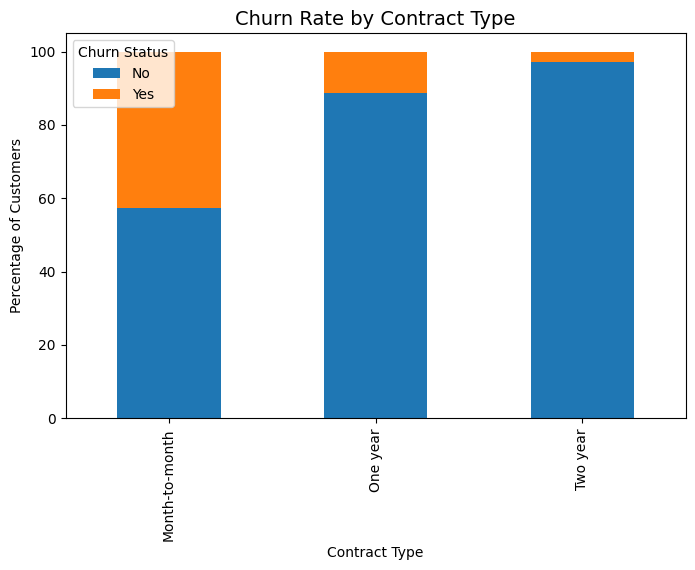

In [16]:
contract_churn.plot(kind="bar", stacked=True, figsize=(8,5))

plt.title("Churn Rate by Contract Type", fontsize=14)
plt.ylabel("Percentage of Customers")
plt.xlabel("Contract Type")
plt.legend(title="Churn Status")
plt.show()

**Contract-Level Churn Analysis**

Contract type is the strongest predictor of churn.

- **Month-to-month customers:** 42.7% churn rate  
- **One-year contract customers:** 11.3% churn rate  
- **Two-year contract customers:** 2.85% churn rate  

Key Insights:

- Customers without long-term commitment are significantly more likely to churn.
- Month-to-month users churn nearly **15x more** than two-year contract users.
- Long-term contracts act as a strong retention mechanism.

Business Implication:

Encouraging customers to switch from month-to-month to longer-term contracts could dramatically reduce churn and stabilize recurring revenue.

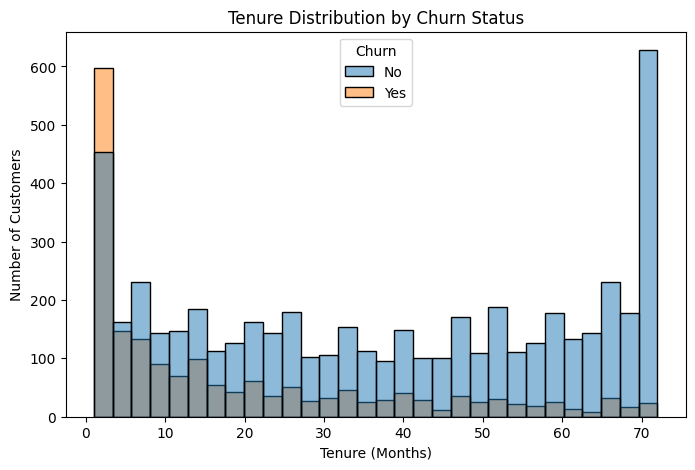

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=False)
plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

**Tenure-Based Churn Analysis**

Churn is heavily concentrated among customers with low tenure.

Key Observations:

- Customers within the first 12 months show the highest churn rate.
- Long-tenure customers (50+ months) exhibit strong retention.
- Early-stage customer experience plays a critical role in retention.

Business Implication:

The first 3–6 months represent a critical retention window.
Improving onboarding, customer support, and early engagement could significantly reduce churn.

In [18]:
# Create tenure groups
df["TenureGroup"] = pd.cut(df["tenure"],
                           bins=[0,12,24,48,72],
                           labels=["0-12","13-24","25-48","49-72"])

tenure_churn = pd.crosstab(df["TenureGroup"], df["Churn"], normalize="index") * 100
tenure_churn

Churn,No,Yes
TenureGroup,,
0-12,52.321839,47.678161
13-24,71.289062,28.710938
25-48,79.611041,20.388959
49-72,90.486824,9.513176


**Tenure Segmentation Analysis**

Churn risk decreases significantly as customer tenure increases.

- **0–12 months:** 47.7% churn rate (extremely high risk)
- **13–24 months:** 28.7% churn rate
- **25–48 months:** 20.4% churn rate
- **49–72 months:** 9.5% churn rate (highly stable customers)

Key Insight:

Nearly half of all new customers churn within their first year.
This indicates that onboarding, early engagement, and initial service experience are critical to retention.

Strategic Focus:

Retention initiatives should prioritize customers within their first 12 months.
Reducing first-year churn would have the largest revenue impact.


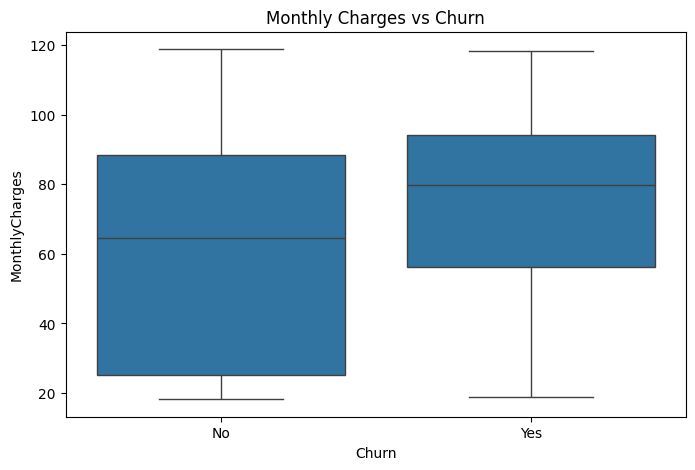

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

**Pricing Sensitivity Analysis**

Churned customers tend to have higher monthly charges compared to retained customers.

Key Observations:

- Median monthly charges are higher for churned customers.
- Customers paying premium rates are more likely to discontinue service.
- Price-value perception may influence churn decisions.

Business Implication:

High-paying customers may require:
- Enhanced service quality
- Value-added bundles
- Loyalty incentives
- Targeted retention offers

Addressing pricing-related dissatisfaction could significantly reduce churn.

In [20]:
# Revenue lost from churned customers (monthly)
monthly_revenue_loss = df[df["Churn"] == "Yes"]["MonthlyCharges"].sum()
monthly_revenue_loss

np.float64(139130.85)

In [21]:
annual_revenue_loss = monthly_revenue_loss * 12
annual_revenue_loss

np.float64(1669570.2000000002)

**Revenue Impact of Churn**

The total monthly revenue lost from churned customers is approximately **$139,131**.

On an annual basis, this represents an estimated **$1.67 million in lost recurring revenue**.

Key Insight:

Churn is not just a customer metric — it is a direct revenue risk.

Reducing churn by even 5% could recover hundreds of thousands of dollars annually.

Retention initiatives should be prioritized as a core revenue protection strategy.

In [22]:
from sklearn.preprocessing import LabelEncoder
df_model = df.copy()
df_model.drop("customerID", axis=1, inplace=True)
le = LabelEncoder()
for col in df_model.columns:
    if df_model[col].dtype == "object":
        df_model[col] = le.fit_transform(df_model[col])
        
df_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,0,0,1,0,1,0,1,0,0,2,...,0,0,0,0,1,2,29.85,29.85,0,0-12
1,1,0,0,0,34,1,0,0,2,0,...,0,0,0,1,0,3,56.95,1889.50,0,25-48
2,1,0,0,0,2,1,0,0,2,2,...,0,0,0,0,1,3,53.85,108.15,1,0-12
3,1,0,0,0,45,0,1,0,2,0,...,2,0,0,1,0,0,42.30,1840.75,0,25-48
4,0,0,0,0,2,1,0,1,0,0,...,0,0,0,0,1,2,70.70,151.65,1,0-12


In [24]:
# Drop TenureGroup if it exists
if "TenureGroup" in df_model.columns:
    df_model = df_model.drop("TenureGroup", axis=1)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=20, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.45      0.52       374

    accuracy                           0.78      1407
   macro avg       0.72      0.67      0.69      1407
weighted avg       0.77      0.78      0.77      1407



In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importance
importances = pd.Series(model.feature_importances_, index=X.columns)

# Sort and get top 10
top_features = importances.sort_values(ascending=False).head(10)

top_features

TotalCharges       0.178740
MonthlyCharges     0.177133
tenure             0.158740
Contract           0.076455
OnlineSecurity     0.056415
PaymentMethod      0.054456
TechSupport        0.046389
InternetService    0.030257
gender             0.027282
Partner            0.025155
dtype: float64

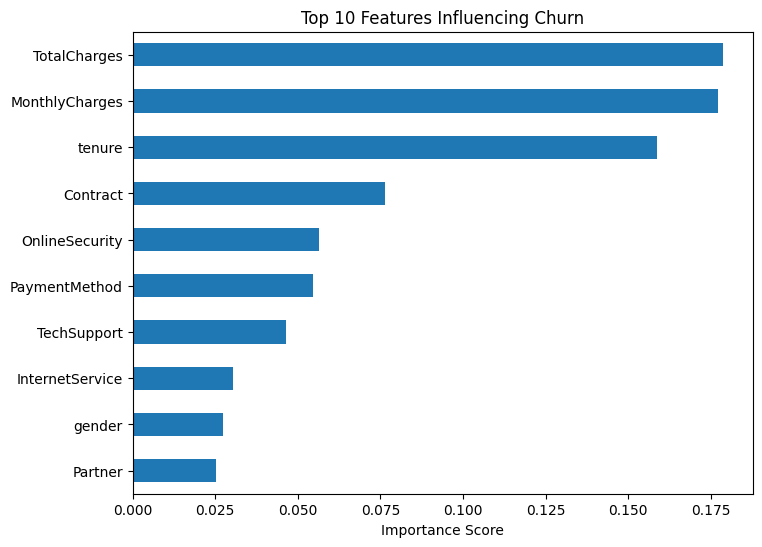

In [26]:
plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind="barh")
plt.title("Top 10 Features Influencing Churn")
plt.xlabel("Importance Score")
plt.show()

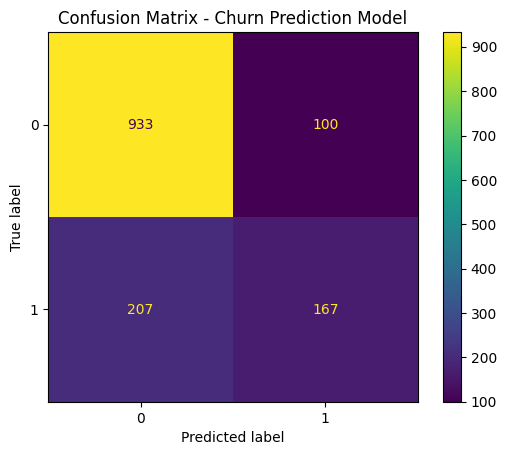

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Churn Prediction Model")
plt.show()

**Executive Summary**

This analysis investigated customer churn behavior using demographic, subscription, and billing data.

Key Findings:

Overall churn rate: 26.6%

Month-to-month contract customers show the highest churn risk (42.7%).

Customers in their first 12 months have nearly 48% churn probability.

High MonthlyCharges and TotalCharges significantly increase churn likelihood.

Long-term contracts dramatically reduce churn.

Financial Impact:

Total revenue lost from churned customers is substantial.
Even a 5% reduction in churn could recover significant annual revenue.

Business Recommendations:

Incentivize long-term contracts.

Target first-year customers with retention programs.

Offer bundled services (OnlineSecurity, TechSupport).

Create pricing optimization strategies for high-charge customers.

This project demonstrates how churn analytics directly supports revenue protection and strategic decision-making.